In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Connect and create sample customer data
conn = sqlite3.connect('customer_analytics.db')

# Creating a table with 1,000 synthetic orders
data = {
    'OrderID': range(1, 11),
    'CustomerID': [101, 102, 101, 103, 104, 102, 101, 105, 103, 104],
    'OrderDate': ['2026-01-10', '2026-01-15', '2026-02-01', '2026-02-10', '2026-02-15',
                  '2026-03-01', '2026-03-05', '2026-03-10', '2026-03-12', '2026-03-15'],
    'OrderAmount': [2500, 1200, 3000, 500, 4500, 1100, 2000, 8000, 600, 4000]
}
df = pd.DataFrame(data)
df.to_sql('orders', conn, index=False, if_exists='replace')

print("Database 'customer_analytics.db' ready for Advanced SQL Analysis!")

Database 'customer_analytics.db' ready for Advanced SQL Analysis!


In [4]:
#Customer Loyalty (Frequency & Total Spend)
query = """
SELECT
    CustomerID,
    COUNT(OrderID) as Total_Orders,
    SUM(OrderAmount) as Total_Spent,
    AVG(OrderAmount) as Avg_Order_Value,
    MAX(OrderDate) as Last_Purchase_Date
FROM orders
GROUP BY CustomerID
ORDER BY Total_Spent DESC;
"""

loyal_customer = pd.read_sql_query(query, conn)
loyal_customer


,CustomerID,Total_Orders,Total_Spent,Avg_Order_Value,Last_Purchase_Date
0,104,2,8500,4250.0,2026-03-15
1,105,1,8000,8000.0,2026-03-10
2,101,3,7500,2500.0,2026-03-05
3,102,2,2300,1150.0,2026-03-01
4,103,2,1100,550.0,2026-03-12


In [5]:
#stats
display(loyal_customer.describe())

,CustomerID,Total_Orders,Total_Spent,Avg_Order_Value
count,5.000000,5.000000,5.000000,5.000000
mean,103.000000,2.000000,5480.000000,3290.000000
std,1.581139,0.707107,3494.567212,2992.365285
min,101.000000,1.000000,1100.000000,550.000000
25%,102.000000,2.000000,2300.000000,1150.000000
50%,103.000000,2.000000,7500.000000,2500.000000
75%,104.000000,2.000000,8000.000000,4250.000000
max,105.000000,3.000000,8500.000000,8000.000000


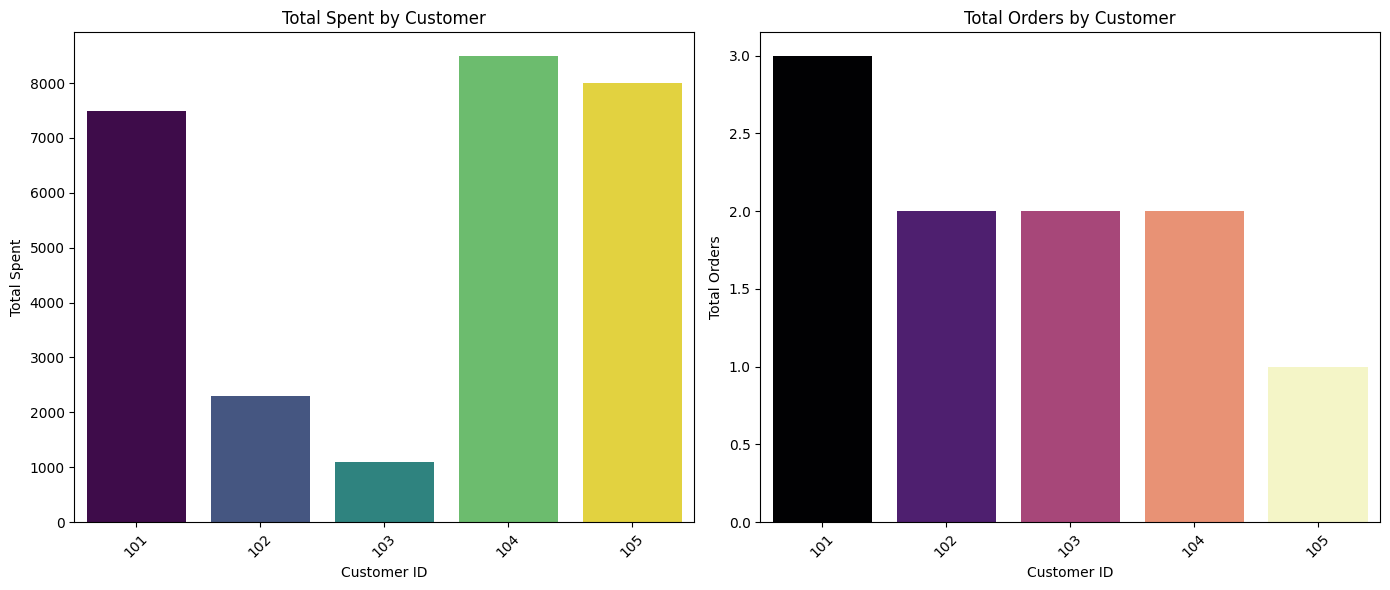

In [6]:
plt.figure(figsize=(14, 6))

# Plot Total Spent by Customer
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.barplot(x='CustomerID', y='Total_Spent', hue='CustomerID', data=loyal_customer, palette='viridis', legend=False)
plt.title('Total Spent by Customer')
plt.xlabel('Customer ID')
plt.ylabel('Total Spent')
plt.xticks(rotation=45)

# Plot Total Orders by Customer
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.barplot(x='CustomerID', y='Total_Orders', hue='CustomerID', data=loyal_customer, palette='magma', legend=False)
plt.title('Total Orders by Customer')
plt.xlabel('Customer ID')
plt.ylabel('Total Orders')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [7]:
#Cumulative Revenue
query = """
SELECT
    OrderDate,
    OrderAmount,
    SUM(OrderAmount) OVER (ORDER BY OrderDate) as Running_Total_Revenue
FROM orders;
"""

running_total = pd.read_sql_query(query, conn)
running_total

,OrderDate,OrderAmount,Running_Total_Revenue
0,2026-01-10,2500,2500
1,2026-01-15,1200,3700
2,2026-02-01,3000,6700
3,2026-02-10,500,7200
4,2026-02-15,4500,11700
5,2026-03-01,1100,12800
6,2026-03-05,2000,14800
7,2026-03-10,8000,22800
8,2026-03-12,600,23400
9,2026-03-15,4000,27400


In [8]:
#Customer Growth: Month-over-Month (MoM) Revenue
query = """
WITH MonthlySales AS (
    SELECT
        strftime('%m', OrderDate) as Month,
        SUM(OrderAmount) as Monthly_Revenue
    FROM orders
    GROUP BY 1
)
SELECT
    Month,
    Monthly_Revenue,
    LAG(Monthly_Revenue) OVER (ORDER BY Month) as Last_Month_Revenue,
    (Monthly_Revenue - LAG(Monthly_Revenue) OVER (ORDER BY Month)) as Revenue_Diff
FROM MonthlySales;
"""

monthly_sales = pd.read_sql_query(query, conn)
monthly_sales

,Month,Monthly_Revenue,Last_Month_Revenue,Revenue_Diff
0,01,3700,NaN,NaN
1,02,8000,3700.0,4300.0
2,03,15700,8000.0,7700.0


In [9]:
#Identifying "Whale" Customers (Percentiles)
query = """
SELECT
    CustomerID,
    SUM(OrderAmount) as Total_Spent,
    NTILE(4) OVER (ORDER BY SUM(OrderAmount) DESC) as Customer_Tier
FROM orders
GROUP BY CustomerID;
"""

customer_tier = pd.read_sql_query(query, conn)
customer_tier

,CustomerID,Total_Spent,Customer_Tier
0,104,8500,1
1,105,8000,1
2,101,7500,2
3,102,2300,3
4,103,1100,4


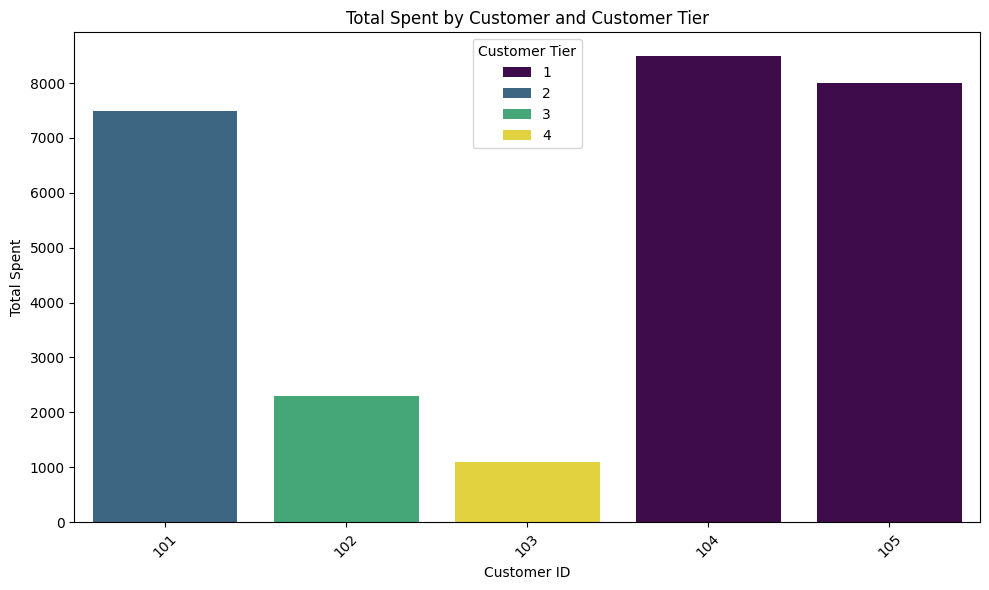

In [10]:
plt.figure(figsize=(10, 6))
sns.barplot(x='CustomerID', y='Total_Spent', hue='Customer_Tier', data=customer_tier, palette='viridis')
plt.title('Total Spent by Customer and Customer Tier')
plt.xlabel('Customer ID')
plt.ylabel('Total Spent')
plt.xticks(rotation=45)
plt.legend(title='Customer Tier')
plt.tight_layout()
plt.show()

In [11]:
#Order Frequency Analysis (Day Gaps)
query = """
SELECT
    CustomerID,
    OrderDate,
    LAG(OrderDate) OVER (PARTITION BY CustomerID ORDER BY OrderDate) as Previous_Order_Date,
    julianday(OrderDate) - julianday(LAG(OrderDate) OVER (PARTITION BY CustomerID ORDER BY OrderDate)) as Days_Between_Orders
FROM orders;
"""

days_between_orders = pd.read_sql_query(query, conn)
days_between_orders

,CustomerID,OrderDate,Previous_Order_Date,Days_Between_Orders
0,101,2026-01-10,None,NaN
1,101,2026-02-01,2026-01-10,22.0
2,101,2026-03-05,2026-02-01,32.0
3,102,2026-01-15,None,NaN
4,102,2026-03-01,2026-01-15,45.0
5,103,2026-02-10,None,NaN
6,103,2026-03-12,2026-02-10,30.0
7,104,2026-02-15,None,NaN
8,104,2026-03-15,2026-02-15,28.0
9,105,2026-03-10,None,NaN


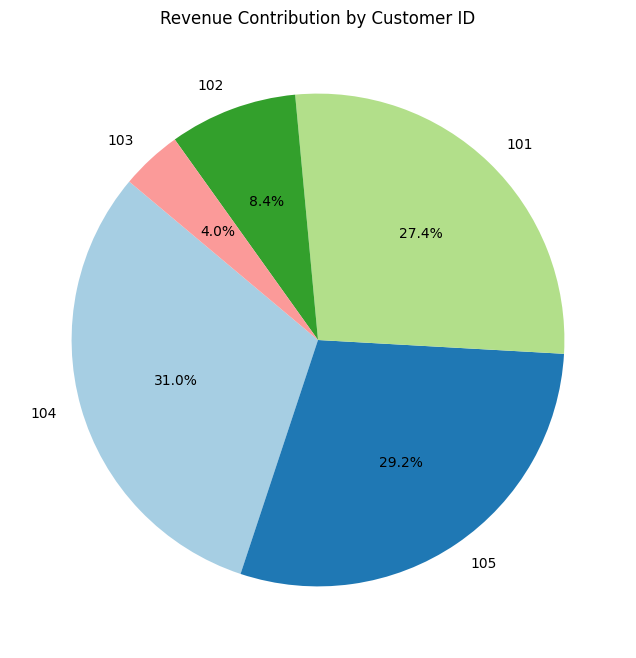

In [12]:
# Pull the Customer Tier data into Python
tier_query = """
SELECT CustomerID, SUM(OrderAmount) as Spend
FROM orders GROUP BY 1 ORDER BY Spend DESC
"""
df_tier = pd.read_sql_query(tier_query, conn)

# Plotting a Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(df_tier['Spend'], labels=df_tier['CustomerID'], autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Revenue Contribution by Customer ID')
plt.show()